In [1]:
# ============================================================
# Imports
# ============================================================
import sys
import numpy as np
import torch
from torch.nn import functional as F
from torch.utils.data import DataLoader
from collections import deque
import matplotlib.pyplot as plt

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import DarcyDataset
from neuralop.utils import count_model_params

In [2]:
# ============================================================
# Helper Functions
# ============================================================

def threshold_field(x, tau=-1, boundary=0.0):
    """
    Maps a real-valued field to a binary-valued coefficient field taking
    values in {3, 12}, as used in the Darcy flow normalisation.

    When tau=-1, applies a hard threshold at `boundary`.
    Otherwise, applies a smooth sigmoid-like approximation via tanh,
    parametrised by tau (higher tau = sharper transition).
    """
    if isinstance(x, np.ndarray):
        if tau == -1:
            return np.where(x < boundary, 3.0, 12.0)
        return 0.5 * np.tanh(tau * x) + 0.5
    else:
        if tau == -1:
            return torch.where(x < boundary,
                               torch.tensor(3.0),
                               torch.tensor(12.0))
        return 0.5 * torch.tanh(tau * x) + 0.5


def sample_gaussian_process(N=64, M=256):
    """
    Samples a Gaussian process on an N x N grid using a spectral
    (Karhunen-Loeve) expansion on a finer M x M grid, then subsamples.

    The covariance operator is the inverse of (−Δ + 9I)², which produces
    smooth, spatially correlated samples suitable as diffusion coefficients.

    Parameters
    ----------
    N : int
        Output grid resolution (coarse).
    M : int
        Internal fine grid resolution used for spectral sampling.

    Returns
    -------
    u_coarse : np.ndarray of shape (N, N)
    """
    h_fine = 1.0 / M
    kx = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    ky = 2 * np.pi * np.fft.fftfreq(M, d=h_fine)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    eigenvalues = KX**2 + KY**2 + 9.0
    covariance_spectrum = 1.0 / eigenvalues**2

    noise = np.random.randn(M, M) + 1j * np.random.randn(M, M)
    u_hat = np.sqrt(covariance_spectrum) * noise
    u_fine = np.fft.ifft2(u_hat).real * M**2

    step = M // N
    u_coarse = u_fine[::step, ::step]
    return u_coarse

In [3]:
# ============================================================
# Data Loading
# ============================================================

def get_data(
    n_train=1_000,
    n_tests=[100, 50],
    train_resolution=64,
    test_resolutions=[64, 128],
    batch_size=32,
    test_batch_sizes=[32, 32],
):
    """
    Loads the Darcy flow dataset, renormalises coefficients to {3, 12},
    and returns data loaders and the data processor.

    Returns
    -------
    train_loader    : DataLoader
    test_loaders    : dict[int, DataLoader]
    data_processor  : DataProcessor
    dataset         : DarcyDataset
    """
    dataset = DarcyDataset(
        root_dir="./darcy_data",
        n_train=n_train,
        n_tests=n_tests,
        train_resolution=train_resolution,
        batch_size=batch_size,
        test_resolutions=test_resolutions,
        test_batch_sizes=test_batch_sizes,
    )

    # Renormalise coefficient fields from {0, 1} to {3, 12}
    for test_set in dataset.test_dbs.values():
        test_set.x = threshold_field(test_set.x, tau=-1, boundary=0.5)
    dataset._train_db.x = threshold_field(dataset._train_db.x, tau=-1, boundary=0.5)

    train_loader = DataLoader(
        dataset.train_db,
        batch_size=batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

    test_loaders = {
        res: DataLoader(
            dataset.test_dbs[res],
            batch_size=test_bsize,
            shuffle=False,
            num_workers=1,
            pin_memory=True,
            persistent_workers=False,
        )
        for res, test_bsize in zip(test_resolutions, test_batch_sizes)
    }

    return train_loader, test_loaders, dataset.data_processor, dataset

In [4]:
# ============================================================
# FNO Training
# ============================================================

def train_FNO(
    train_loader,
    data_processor,
    device,
    n_modes=(25, 25),
    hidden_channels=32,
    n_layers=4,
    factorization="tucker",
    nonlinearity=F.gelu,
    n_epochs=150,
    save_dir="./checkpoints",
):
    """
    Instantiates and trains an FNO on the Darcy flow operator.

    Returns
    -------
    model : trained FNO
    """
    model = FNO(
        n_modes=n_modes,
        in_channels=1,
        out_channels=1,
        hidden_channels=hidden_channels,
        n_layers=n_layers,
        factorization=factorization,
        non_linearity=nonlinearity,
    ).to(device)

    print(f"\nFNO parameter count: {count_model_params(model):,}")
    sys.stdout.flush()

    optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

    h1loss = H1Loss(d=2)
    l2loss = LpLoss(d=2, p=2)

    # Register safe globals for serialisation
    torch.serialization.add_safe_globals([torch._C._nn.gelu])
    torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

    trainer = Trainer(
        model=model,
        n_epochs=n_epochs,
        device=device,
        data_processor=data_processor,
        wandb_log=False,
        eval_interval=5,
        use_distributed=False,
    )

    trainer.train(
        train_loader=train_loader,
        test_loaders={},
        optimizer=optimizer,
        scheduler=scheduler,
        regularizer=False,
        training_loss=h1loss,
        eval_losses={"h1": h1loss, "l2": l2loss},
        save_every=5,
        save_dir=save_dir,
    )

    return model

In [5]:
def run_MCMC(
    model,
    data_processor,
    true_observations,
    device,
    delta=0.00025,
    n_iterations=80_000,
    tau=-1,
    subsample_ratio=1,
    target_acceptance=0.234,
    adapt_interval=500,
    adapt_cutoff=30_000,
    delta_min=1e-6,
    delta_max=0.49,
    seed=None,
):
    if seed is not None:
        np.random.seed(seed)
        torch.manual_seed(seed)

    H, W = true_observations.shape[-2], true_observations.shape[-1]
    assert H == W, "Observation grid must be square."
    N = H

    # ------------------------------------------------------------------
    # Pre-fetch normalisers once — avoids a .to(device) call every
    # likelihood evaluation
    # ------------------------------------------------------------------
    out_mean = data_processor.out_normalizer.mean.to(device)
    out_std  = data_processor.out_normalizer.std.to(device)

    true_observations_full   = true_observations.to(device)
    true_observations_sparse = true_observations_full[:, :, ::subsample_ratio, ::subsample_ratio]

    sigma   = true_observations.std().item()
    sigma_sq = sigma ** 2

    # ------------------------------------------------------------------
    # Pre-allocate a reusable input buffer on the GPU — avoids
    # allocating a new tensor and transferring from CPU every iteration
    # ------------------------------------------------------------------
    input_buffer = torch.empty(1, 1, N, N, dtype=torch.float32, device=device)

    def log_likelihood(theta_np):
        """
        Evaluates the Gaussian log-likelihood given a numpy coefficient
        field, using the pre-allocated GPU buffer to avoid repeated
        allocation and host-device transfers.
        """
        input_buffer.copy_(torch.from_numpy(theta_np))
        with torch.no_grad():
            u_pred = model(input_buffer) * out_std + out_mean
        u_pred_sparse = u_pred[:, :, ::subsample_ratio, ::subsample_ratio]
        # Keep as tensor to avoid GPU->CPU sync until accept/reject step
        ll = -0.5 * torch.sum((true_observations_sparse - u_pred_sparse[0, 0]) ** 2) / sigma_sq
        return ll

    # ------------------------------------------------------------------
    # Initialise chain
    # ------------------------------------------------------------------
    u_current     = sample_gaussian_process(N=N)
    theta_current = threshold_field(u_current, tau=tau)
    ll_current    = log_likelihood(theta_current).item()

    theta_evolution   = []
    loss_evolution    = []
    accepted          = []
    nll_window        = deque(maxlen=200)
    n_accepted_window = 0
    adapting          = True

    # ------------------------------------------------------------------
    # pCN sampling loop
    # ------------------------------------------------------------------
    for i in range(n_iterations):

        # --- pCN proposal ---
        u_proposal     = np.sqrt(1 - 2 * delta) * u_current + np.sqrt(2 * delta) * sample_gaussian_process(N=N)
        theta_proposal = threshold_field(u_proposal, tau=tau)

        # --- Accept / reject ---
        ll_proposal  = log_likelihood(theta_proposal)
        log_ratio    = ll_proposal.item() - ll_current  # single GPU->CPU sync per iteration

        if np.log(np.random.rand()) < log_ratio:        # avoids redundant min(1, exp(...))
            u_current     = u_proposal
            theta_current = theta_proposal
            ll_current    = log_ratio + ll_current
            accepted.append(1)
            n_accepted_window += 1
        else:
            accepted.append(0)

        theta_evolution.append(theta_current)
        loss_evolution.append(ll_current)
        nll_window.append(-ll_current)

        # --- Periodic diagnostics and delta adaptation ---
        if (i + 1) % adapt_interval == 0:
            acceptance_rate   = n_accepted_window / adapt_interval
            n_accepted_window = 0

            if adapting:
                factor = np.exp(acceptance_rate - target_acceptance)
                delta  = float(np.clip(delta * factor, delta_min, delta_max))

                if (i + 1) >= adapt_cutoff:
                    adapting = False
                    print(f">>> Adaptation frozen at delta = {delta:.6f}")

            print(f"Iteration {i+1:>6}/{n_iterations} | "
                  f"Acceptance rate: {acceptance_rate:.3f} | "
                  f"Delta: {delta:.6f} | "
                  f"Adapting: {adapting} | "
                  f"Avg NLL (last 200): {np.mean(nll_window):.3f} | "
                  f"Subsampling: 1/{subsample_ratio**2} "
                  f"({true_observations_sparse.numel()} obs points)")

    return {
        "theta_evolution": theta_evolution,
        "loss_evolution":  loss_evolution,
        "accepted":        accepted,
        "best_theta":      theta_current,
        "best_u":          u_current,
        "sigma":           sigma,
        "delta_final":     delta,
    }

In [6]:
# ============================================================
# Main Pipeline
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader, test_loaders, data_processor, dataset = get_data()

true_field        = dataset.test_dbs[64].x[0, 0].unsqueeze(0).unsqueeze(0)
true_observations = dataset.test_dbs[64].y[0, 0].unsqueeze(0).unsqueeze(0)

model = train_FNO(train_loader, data_processor, device)
model = model.to(device)


Using device: cuda
Loading test db for resolution 64 with 100 samples 
Loading test db for resolution 128 with 50 samples 

FNO parameter count: 2,698,289


/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/torch/nn/modules/module.py:1790: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)
/home/ghazi/anaconda3/envs/darcy-env/lib/python3.11/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


In [7]:
# # Example: subsample_ratio=4 retains every 4th point → 16x16 effective observations from 64x64
# result = run_MCMC(model, data_processor, true_observations, device,
#                   n_iterations=10_000, subsample_ratio=4, seed=42)



In [8]:
# fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300, constrained_layout=True)
# fields1 = [
#     true_field.cpu().numpy()[0, 0],
#     result["best_theta"],
# ]
# titles1 = [
#     "True Diffusion Coefficient",
#     "Inferred Diffusion Coefficient",
# ]
# for ax, field, title in zip(axs1, fields1, titles1):
#     im = ax.imshow(field, extent=[0, 1, 0, 1], origin='lower')
#     ax.set_title(title, fontsize=14, loc='center', pad=6)
#     ax.tick_params(labelsize=9)

# fig1.colorbar(im, ax=axs1, fraction=0.03, pad=0.02, shrink=1.0, aspect=20)
# # plt.savefig('figures_for_report/single_true_vs_inferred_coefficients.png', bbox_inches='tight', dpi=300)
# plt.show()

In [9]:
# # ============================================================
# # Ablation Study: H1 Loss vs Subsampling Ratio
# # ============================================================

# h1loss = H1Loss(d=2)
# l2loss = LpLoss(d=2, p=2)

# subsample_ratios = [1, 2, 4, 8, 16]

# # True coefficient tensor for baseline FNO prediction
# theta_true_tensor = true_field.to(device)

# # Baseline: FNO prediction under the true coefficient
# with torch.no_grad():
#     fno_true_pred = model(theta_true_tensor).cpu()[0, 0]

# fno_true_norm = (fno_true_pred - fno_true_pred.min()) / (fno_true_pred.max() - fno_true_pred.min())
# fno_true_norm = fno_true_norm.unsqueeze(0).unsqueeze(0)
# h1_baseline   = h1loss(fno_true_norm, true_observations.cpu()).item()
# l2_baseline   = l2loss(fno_true_norm, true_observations.cpu()).item()

# print(f"Baseline H1 loss (true coefficient): {h1_baseline:.4f}\n")
# print(f"Baseline L2 loss (true coefficient): {l2_baseline:.4f}\n")

In [10]:
# # ------------------------------------------------------------------
# # Run MCMC for each subsampling ratio and record H1 loss
# # ------------------------------------------------------------------
# h1_losses = {}
# l2_losses = {}

# for ratio in subsample_ratios:
#     print(f"{'='*60}")
#     print(f"Running MCMC with subsampling ratio = {ratio} "
#           f"({true_observations.shape[-1] // ratio}x{true_observations.shape[-2] // ratio} "
#           f"effective observations)")
#     print(f"{'='*60}")

#     result = run_MCMC(
#         model, data_processor, true_observations, device,
#         n_iterations=80_000,
#         subsample_ratio=ratio,
#         seed=42,
#     )

#     # Posterior mean coefficient
#     theta_evolution  = result["theta_evolution"]
#     posterior_mean   = np.mean(theta_evolution[-10_000::1_000], axis=0)

#     # Reconstruct flow field from posterior mean coefficient
#     posterior_mean_tensor = (
#         torch.tensor(posterior_mean, dtype=torch.float32)
#         .unsqueeze(0).unsqueeze(0)
#         .to(device)
#     )
#     with torch.no_grad():
#         predicted_solution = model(posterior_mean_tensor).cpu().numpy()[0, 0]

#     # Normalise and compute H1 loss
#     pred = torch.tensor(predicted_solution).unsqueeze(0).unsqueeze(0)
#     pred_norm = (pred - pred.min()) / (pred.max() - pred.min())
#     h1 = h1loss(pred_norm, true_observations.cpu()).item()
#     l2 = l2loss(pred_norm, true_observations.cpu()).item()

#     h1_losses[ratio] = h1
#     l2_losses[ratio] = l2
#     print(f"H1 loss at subsampling ratio {ratio}: {h1:.4f}")
#     print(f"L2 loss at subsampling ratio {ratio}: {l2:.4f}\n")

In [11]:
# # ------------------------------------------------------------------
# # Plot
# # ------------------------------------------------------------------
# ratios    = list(h1_losses.keys())
# h1_values = list(h1_losses.values())
# l2_values = list(l2_losses.values())
# x         = np.arange(len(ratios))
# xlabels   = ["Full" if r == 1 else f"1/{r**2}" for r in ratios]

# fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

# ax.plot(x, h1_values, marker='o', linewidth=2, label='Inferred ($H^1$)')
# ax.plot(x, l2_values, marker='s', linewidth=2, label='Inferred ($L^2$)')
# ax.axhline(h1_baseline, color='steelblue', linestyle='--', linewidth=1.5, label='True coefficient ($H^1$)')
# ax.axhline(l2_baseline, color='darkorange', linestyle='--', linewidth=1.5, label='True coefficient ($L^2$)')

# ax.set_xlabel("Fraction of observations retained", fontsize=12)
# ax.set_ylabel("Relative loss", fontsize=12)
# ax.set_title("Inference quality vs. observation sparsity", fontsize=13)
# ax.set_xticks(x)
# ax.set_xticklabels(xlabels)
# ax.legend(fontsize=10)
# ax.tick_params(labelsize=9)

# plt.tight_layout()
# plt.savefig("figures_for_report/ablation_subsampling_h1_l2.png", bbox_inches='tight', dpi=300)
# plt.show()

# # ------------------------------------------------------------------
# # Summary table
# # ------------------------------------------------------------------
# print("\nSummary")
# print(f"{'Ratio':<10} {'Obs points':<15} {'H1 Loss':<12} {'L2 Loss':<12}")
# print("-" * 49)
# for r in ratios:
#     n_obs = (true_observations.shape[-1] // r) ** 2
#     print(f"{'Full' if r == 1 else f'1/{r**2}':<10} {n_obs:<15} {h1_losses[r]:.4f}{'':<8} {l2_losses[r]:.4f}")
# print(f"\nBaseline (true coeff): H1 = {h1_baseline:.4f} | L2 = {l2_baseline:.4f}")

In [32]:
# ============================================================
# Ablation Study: H1 & L2 Loss vs Subsampling Ratio
# Averaged over multiple inference problems
# ============================================================

h1loss = H1Loss(d=2)
l2loss = LpLoss(d=2, p=2)

subsample_ratios = [1, 2, 4, 8, 16]
n_samples        = 8



In [33]:
# ------------------------------------------------------------------
# Baselines: averaged over the same n_samples test problems
# ------------------------------------------------------------------
h1_baselines = []
l2_baselines = []

for i in range(n_samples):
    true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
    true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

    with torch.no_grad():
        fno_true_pred = model(true_field_i.to(device)).cpu()[0, 0]

    # Normalise both prediction and target consistently
    fno_norm  = (fno_true_pred - fno_true_pred.min()) / (fno_true_pred.max() - fno_true_pred.min())
    fno_norm  = fno_norm.unsqueeze(0).unsqueeze(0)

    obs        = true_observations_i.cpu()[0, 0]
    obs_norm   = (obs - obs.min()) / (obs.max() - obs.min())
    obs_norm   = obs_norm.unsqueeze(0).unsqueeze(0)

    h1_baselines.append(h1loss(fno_norm, obs_norm).item())
    l2_baselines.append(l2loss(fno_norm, obs_norm).item())

h1_baseline_mean = np.mean(h1_baselines)
h1_baseline_std  = np.std(h1_baselines)
l2_baseline_mean = np.mean(l2_baselines)
l2_baseline_std  = np.std(l2_baselines)

print(f"Baseline H1 (true coeff): {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f}")
print(f"Baseline L2 (true coeff): {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}\n")

Baseline H1 (true coeff): 0.0934 ± 0.0287
Baseline L2 (true coeff): 0.0326 ± 0.0152



In [34]:
import os
import json

save_path = "ablation_results/subsampling"
os.makedirs(save_path, exist_ok=True)

# ------------------------------------------------------------------
# Load existing results if present, otherwise initialise empty
# ------------------------------------------------------------------
results_file = f"{save_path}/losses.json"

if os.path.exists(results_file):
    with open(results_file) as f:
        saved = json.load(f)
    h1_losses = {int(k): v for k, v in saved["h1"].items()}
    l2_losses = {int(k): v for k, v in saved["l2"].items()}
    print("Resuming from saved results:")
    for r in subsample_ratios:
        n_done = len(h1_losses.get(r, []))
        print(f"  ratio={r}: {n_done}/{n_samples} samples completed")
else:
    h1_losses = {r: [] for r in subsample_ratios}
    l2_losses = {r: [] for r in subsample_ratios}
    print("No saved results found, starting from scratch.")

def save_results():
    with open(results_file, "w") as f:
        json.dump(
            {"h1": {str(k): v for k, v in h1_losses.items()},
             "l2": {str(k): v for k, v in l2_losses.items()}},
            f, indent=2,
        )

# ------------------------------------------------------------------
# Ablation loop — skips already completed (ratio, sample) pairs
# ------------------------------------------------------------------
for ratio in subsample_ratios:
    n_completed = len(h1_losses.get(ratio, []))

    if n_completed >= n_samples:
        print(f"ratio={ratio}: all {n_samples} samples already done, skipping.")
        continue

    print(f"{'='*60}")
    print(f"Subsampling ratio = {ratio} | "
          f"Resuming from sample {n_completed + 1}/{n_samples}")
    print(f"{'='*60}")

    for i in range(n_completed, n_samples):
        true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
        true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

        result = run_MCMC(
            model, data_processor, true_observations_i, device,
            n_iterations=60_000,
            adapt_cutoff=20_000,
            subsample_ratio=ratio,
            seed=42 + i,
        )

        theta_evolution       = result["theta_evolution"]
        posterior_mean        = np.mean(theta_evolution[-10_000::1_000], axis=0)
        posterior_mean_tensor = (
            torch.tensor(posterior_mean, dtype=torch.float32)
            .unsqueeze(0).unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():
            predicted_solution = model(posterior_mean_tensor).cpu()[0, 0]

        pred_range = predicted_solution.max() - predicted_solution.min()
        obs        = true_observations_i.cpu()[0, 0]
        obs_range  = obs.max() - obs.min()

        if pred_range < 1e-8 or obs_range < 1e-8:
            print(f"  Warning: near-constant field at ratio={ratio}, sample={i+1}. Skipping.")
            h1_losses[ratio].append(float('nan'))
            l2_losses[ratio].append(float('nan'))
        else:
            pred_norm = ((predicted_solution - predicted_solution.min()) / pred_range).unsqueeze(0).unsqueeze(0)
            obs_norm  = ((obs - obs.min()) / obs_range).unsqueeze(0).unsqueeze(0)

            h1_losses[ratio].append(h1loss(pred_norm, obs_norm).item())
            l2_losses[ratio].append(l2loss(pred_norm, obs_norm).item())

        print(f"  Sample {i+1}/{n_samples} | "
              f"H1 = {h1_losses[ratio][-1]:.4f} | "
              f"L2 = {l2_losses[ratio][-1]:.4f}")

        save_results()  # write to disk after every sample

print("\nAll done.")

Resuming from saved results:
  ratio=1: 8/8 samples completed
  ratio=2: 8/8 samples completed
  ratio=4: 8/8 samples completed
  ratio=8: 8/8 samples completed
  ratio=16: 8/8 samples completed
ratio=1: all 8 samples already done, skipping.
ratio=2: all 8 samples already done, skipping.
ratio=4: all 8 samples already done, skipping.
ratio=8: all 8 samples already done, skipping.
ratio=16: all 8 samples already done, skipping.

All done.


In [35]:
# Aggregate mean and std across samples
with open(results_file) as f:
    saved = json.load(f)
h1_losses = {int(k): v for k, v in saved["h1"].items()}
l2_losses = {int(k): v for k, v in saved["l2"].items()}

h1_means = np.array([np.nanmean(h1_losses[r]) for r in subsample_ratios])
h1_stds  = np.array([np.nanstd(h1_losses[r])  for r in subsample_ratios])
l2_means = np.array([np.nanmean(l2_losses[r]) for r in subsample_ratios])
l2_stds  = np.array([np.nanstd(l2_losses[r])  for r in subsample_ratios])

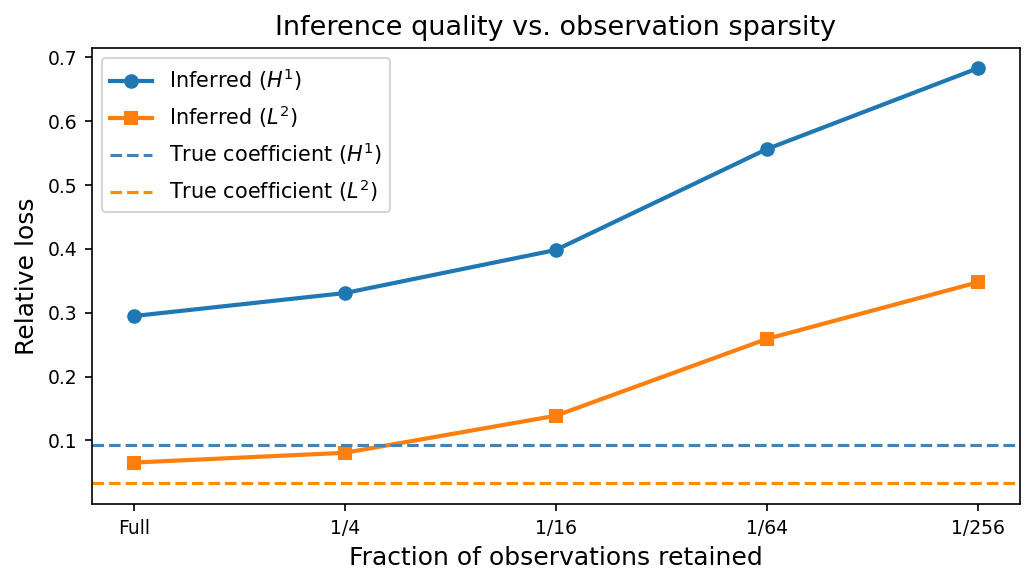

In [36]:
# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
show_error_bars  = False   # <-- toggle error bars here


x       = np.arange(len(subsample_ratios))
xlabels = ["Full" if r == 1 else f"1/{r**2}" for r in subsample_ratios]

fig, ax = plt.subplots(figsize=(7, 4), dpi=150)

eb_kwargs = dict(capsize=4, linewidth=2)

if show_error_bars:
    ax.errorbar(x, h1_means, yerr=h1_stds, marker='o', label='Inferred ($H^1$)', **eb_kwargs)
    ax.errorbar(x, l2_means, yerr=l2_stds, marker='s', label='Inferred ($L^2$)', **eb_kwargs)
else:
    ax.plot(x, h1_means, marker='o', linewidth=2, label='Inferred ($H^1$)')
    ax.plot(x, l2_means, marker='s', linewidth=2, label='Inferred ($L^2$)')

# Baseline bands — shaded ± 1 std, dashed mean line
for mean, std, color, label in [
    (h1_baseline_mean, h1_baseline_std, 'steelblue',  'True coefficient ($H^1$)'),
    (l2_baseline_mean, l2_baseline_std, 'darkorange', 'True coefficient ($L^2$)'),
]:
    ax.axhline(mean, color=color, linestyle='--', linewidth=1.5, label=label)
    if show_error_bars:
        ax.axhspan(mean - std, mean + std, color=color, alpha=0.10)

ax.set_xlabel("Fraction of observations retained", fontsize=12)
ax.set_ylabel("Relative loss", fontsize=12)
ax.set_title("Inference quality vs. observation sparsity", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(xlabels)
ax.legend(fontsize=10)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("figures_for_report/ablation_subsampling_h1_l2.png", bbox_inches='tight', dpi=300)
plt.show()

In [37]:
# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print("\nSummary (mean ± std over 10 samples)")
print(f"{'Ratio':<10} {'Obs points':<15} {'H1 Loss':<22} {'L2 Loss':<22}")
print("-" * 69)
for r, h1_m, h1_s, l2_m, l2_s in zip(subsample_ratios, h1_means, h1_stds, l2_means, l2_stds):
    n_obs = (true_observations_i.shape[-1] // r) ** 2
    label = "Full" if r == 1 else f"1/{r**2}"
    print(f"{label:<10} {n_obs:<15} {h1_m:.4f} ± {h1_s:.4f}    {l2_m:.4f} ± {l2_s:.4f}")
print(f"\nBaseline: H1 = {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f} | "
      f"L2 = {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}")


Summary (mean ± std over 10 samples)
Ratio      Obs points      H1 Loss                L2 Loss               
---------------------------------------------------------------------
Full       4096            0.2948 ± 0.0577    0.0652 ± 0.0159
1/4        1024            0.3307 ± 0.0474    0.0805 ± 0.0119
1/16       256             0.3983 ± 0.0643    0.1385 ± 0.0383
1/64       64              0.5563 ± 0.0867    0.2588 ± 0.0547
1/256      16              0.6830 ± 0.0847    0.3477 ± 0.0946

Baseline: H1 = 0.0934 ± 0.0287 | L2 = 0.0326 ± 0.0152


In [38]:
# ============================================================
# Ablation Study: H1 & L2 Loss vs Number of Fourier Modes
# Averaged over multiple inference problems, with resume support
# ============================================================

import os
import json

h1loss = H1Loss(d=2)
l2loss = LpLoss(d=2, p=2)

fourier_modes_list = [1, 6, 12, 18, 24, 30]
n_samples          = 5
show_error_bars    = True

save_path    = "ablation_results/fourier_modes"
results_file = f"{save_path}/losses.json"
os.makedirs(save_path, exist_ok=True)

# ------------------------------------------------------------------
# Load existing results if present, otherwise initialise empty
# ------------------------------------------------------------------
if os.path.exists(results_file):
    with open(results_file) as f:
        saved = json.load(f)
    h1_losses = {int(k): v for k, v in saved["h1"].items()}
    l2_losses = {int(k): v for k, v in saved["l2"].items()}
    print("Resuming from saved results:")
    for k in fourier_modes_list:
        n_done = len(h1_losses.get(k, []))
        print(f"  k_max={k}: {n_done}/{n_samples} samples completed")
else:
    h1_losses = {k: [] for k in fourier_modes_list}
    l2_losses = {k: [] for k in fourier_modes_list}
    print("No saved results found, starting from scratch.")

def save_results():
    with open(results_file, "w") as f:
        json.dump(
            {"h1": {str(k): v for k, v in h1_losses.items()},
             "l2": {str(k): v for k, v in l2_losses.items()}},
            f, indent=2,
        )

# ------------------------------------------------------------------
# Run for each Fourier mode setting — skips completed (k_max, sample) pairs
# ------------------------------------------------------------------
for k_max in fourier_modes_list:
    n_completed = len(h1_losses.get(k_max, []))

    if n_completed >= n_samples:
        print(f"k_max={k_max}: all {n_samples} samples already done, skipping.")
        continue

    print(f"{'='*60}")
    print(f"Training FNO with Fourier modes = ({k_max}, {k_max}) | "
          f"Resuming from sample {n_completed + 1}/{n_samples}")
    print(f"{'='*60}")

    # Always retrain — training is deterministic given the same seed
    model_k = train_FNO(
        train_loader, data_processor, device,
        n_modes=(k_max, k_max),
    )
    model_k.eval()

    for i in range(n_completed, n_samples):
        true_field_i        = dataset.test_dbs[64].x[i].unsqueeze(0)
        true_observations_i = dataset.test_dbs[64].y[i].unsqueeze(0)

        result = run_MCMC(
            model_k, data_processor, true_observations_i, device,
            n_iterations=40_000,
            adapt_cutoff=20_000,
            subsample_ratio=1,
            seed=42 + i,
        )

        theta_evolution       = result["theta_evolution"]
        posterior_mean        = np.mean(theta_evolution[-10_000::1_000], axis=0)
        posterior_mean_tensor = (
            torch.tensor(posterior_mean, dtype=torch.float32)
            .unsqueeze(0).unsqueeze(0)
            .to(device)
        )

        with torch.no_grad():
            predicted_solution = model_k(posterior_mean_tensor).cpu()[0, 0]

        pred_range = predicted_solution.max() - predicted_solution.min()
        obs        = true_observations_i.cpu()[0, 0]
        obs_range  = obs.max() - obs.min()

        if pred_range < 1e-8 or obs_range < 1e-8:
            print(f"  Warning: near-constant field at k_max={k_max}, sample={i+1}. Skipping.")
            h1_losses[k_max].append(float('nan'))
            l2_losses[k_max].append(float('nan'))
        else:
            pred_norm = ((predicted_solution - predicted_solution.min()) / pred_range).unsqueeze(0).unsqueeze(0)
            obs_norm  = ((obs - obs.min()) / obs_range).unsqueeze(0).unsqueeze(0)
            h1_losses[k_max].append(h1loss(pred_norm, obs_norm).item())
            l2_losses[k_max].append(l2loss(pred_norm, obs_norm).item())

        print(f"  Sample {i+1}/{n_samples} | "
              f"H1 = {h1_losses[k_max][-1]:.4f} | "
              f"L2 = {l2_losses[k_max][-1]:.4f}")

        save_results()

    print(f"  Mean H1 = {np.nanmean(h1_losses[k_max]):.4f} ± {np.nanstd(h1_losses[k_max]):.4f}")
    print(f"  Mean L2 = {np.nanmean(l2_losses[k_max]):.4f} ± {np.nanstd(l2_losses[k_max]):.4f}\n")

print("\nAll done.")

Resuming from saved results:
  k_max=1: 5/5 samples completed
  k_max=6: 5/5 samples completed
  k_max=12: 5/5 samples completed
  k_max=18: 5/5 samples completed
  k_max=24: 5/5 samples completed
  k_max=30: 5/5 samples completed
k_max=1: all 5 samples already done, skipping.
k_max=6: all 5 samples already done, skipping.
k_max=12: all 5 samples already done, skipping.
k_max=18: all 5 samples already done, skipping.
k_max=24: all 5 samples already done, skipping.
k_max=30: all 5 samples already done, skipping.

All done.


In [39]:
h1_means = np.array([np.nanmean(h1_losses[k]) for k in fourier_modes_list])
h1_stds  = np.array([np.nanstd(h1_losses[k])  for k in fourier_modes_list])
l2_means = np.array([np.nanmean(l2_losses[k]) for k in fourier_modes_list])
l2_stds  = np.array([np.nanstd(l2_losses[k])  for k in fourier_modes_list])

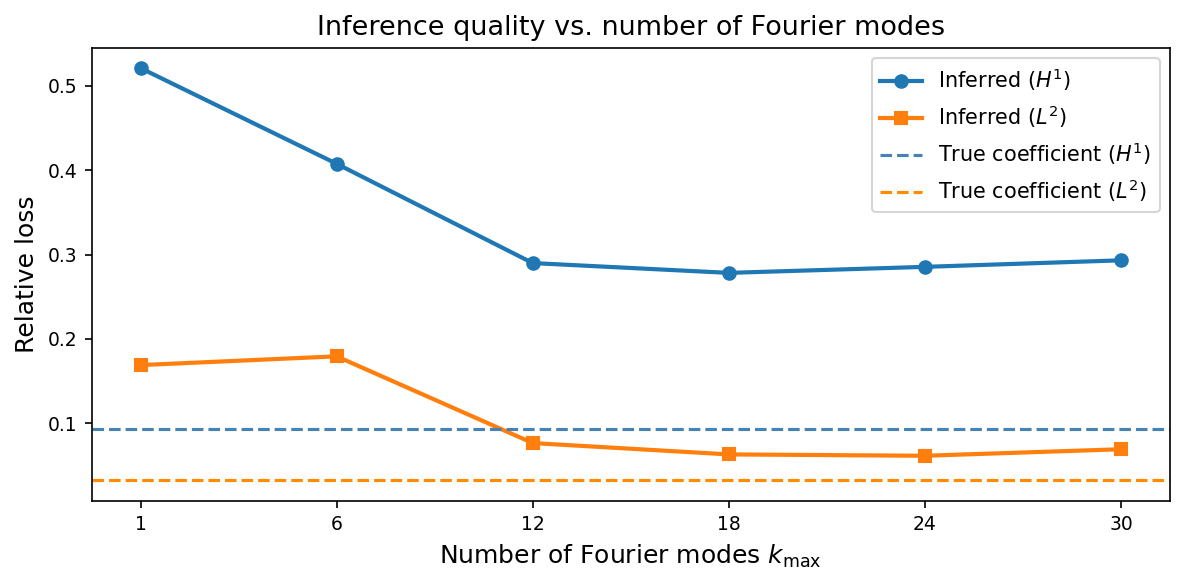


Summary (mean ± std over 5 samples)
k_max      H1 Loss                   L2 Loss                  
------------------------------------------------------------
1          0.5209 ± 0.0529         0.1691 ± 0.0219
6          0.4076 ± 0.2992         0.1795 ± 0.2356
12         0.2899 ± 0.0788         0.0767 ± 0.0264
18         0.2783 ± 0.0711         0.0633 ± 0.0169
24         0.2854 ± 0.0760         0.0617 ± 0.0176
30         0.2932 ± 0.0707         0.0694 ± 0.0257

Baseline (true coeff): H1 = 0.0934 ± 0.0287 | L2 = 0.0326 ± 0.0152


In [40]:
# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
show_error_bars    = False  # <-- toggle error bars here


x = np.arange(len(fourier_modes_list))

fig, ax = plt.subplots(figsize=(8, 4), dpi=150)

eb_kwargs = dict(capsize=4, linewidth=2)

if show_error_bars:
    ax.errorbar(x, h1_means, yerr=h1_stds, marker='o', label='Inferred ($H^1$)', **eb_kwargs)
    ax.errorbar(x, l2_means, yerr=l2_stds, marker='s', label='Inferred ($L^2$)', **eb_kwargs)
else:
    ax.plot(x, h1_means, marker='o', linewidth=2, label='Inferred ($H^1$)')
    ax.plot(x, l2_means, marker='s', linewidth=2, label='Inferred ($L^2$)')

for mean, std, color, label in [
    (h1_baseline_mean, h1_baseline_std, 'steelblue',  'True coefficient ($H^1$)'),
    (l2_baseline_mean, l2_baseline_std, 'darkorange', 'True coefficient ($L^2$)'),
]:
    ax.axhline(mean, color=color, linestyle='--', linewidth=1.5, label=label)
    if show_error_bars:
        ax.axhspan(mean - std, mean + std, color=color, alpha=0.10)

ax.set_xlabel("Number of Fourier modes $k_{\\max}$", fontsize=12)
ax.set_ylabel("Relative loss", fontsize=12)
ax.set_title("Inference quality vs. number of Fourier modes", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([str(k) for k in fourier_modes_list])
ax.legend(fontsize=10)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig("figures_for_report/ablation_fourier_modes_h1_l2.png", bbox_inches='tight', dpi=300)
plt.show()

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
print(f"\nSummary (mean ± std over {n_samples} samples)")
print(f"{'k_max':<10} {'H1 Loss':<25} {'L2 Loss':<25}")
print("-" * 60)
for k, h1_m, h1_s, l2_m, l2_s in zip(fourier_modes_list, h1_means, h1_stds, l2_means, l2_stds):
    print(f"{k:<10} {h1_m:.4f} ± {h1_s:.4f}         {l2_m:.4f} ± {l2_s:.4f}")
print(f"\nBaseline (true coeff): H1 = {h1_baseline_mean:.4f} ± {h1_baseline_std:.4f} | "
      f"L2 = {l2_baseline_mean:.4f} ± {l2_baseline_std:.4f}")